<a href="https://colab.research.google.com/github/JunpyoLee-985/BME450-project/blob/main/train_cardiomegaly_simple_cnn_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# ========================================================
# 0. Install and import packages
# ========================================================

!pip -q install kaggle

import os
import glob
import shutil
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from PIL import Image


In [15]:
import os
from getpass import getpass

token = "KGAT_3c5ae74d8f919d72dbe7d26446aa2f59".strip()

os.makedirs("/root/.kaggle", exist_ok=True)

# New Kaggle CLI token method
with open("/root/.kaggle/access_token", "w") as f:
    f.write(token)

os.chmod("/root/.kaggle/access_token", 0o600)

# Also set environment variable for this Colab runtime
os.environ["KAGGLE_API_TOKEN"] = token

print("Token saved to /root/.kaggle/access_token")
print("KAGGLE_API_TOKEN environment variable set.")

Token saved to /root/.kaggle/access_token
KAGGLE_API_TOKEN environment variable set.


In [17]:
# =========================================================
# 2. Download Kaggle dataset
# =========================================================
# Recommended dataset:
# https://www.kaggle.com/datasets/rahimanshu/cardiomegaly-disease-prediction-using-cnn


KAGGLE_DATASET = "rahimanshu/cardiomegaly-disease-prediction-using-cnn"

project_root = "/content/cardiomegaly_project"
raw_dir = os.path.join(project_root, "raw")
dataset_dir = os.path.join(project_root, "dataset")
figures_dir = os.path.join(project_root, "figures")
outputs_dir = os.path.join(project_root, "outputs")

for d in [raw_dir, dataset_dir, figures_dir, outputs_dir]:
    os.makedirs(d, exist_ok=True)

print("Downloading dataset:", KAGGLE_DATASET)
!kaggle datasets download -d {KAGGLE_DATASET} -p "{raw_dir}" --unzip

print("\nDownloaded files preview:")
!find "{raw_dir}" -maxdepth 4 -type f | head -50

# =========================================================
# 3. Helper functions
# =========================================================

def is_image_file(path):
    return Path(path).suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]

def safe_copy_image(src, dst):
    """
    Opens image, converts to RGB, and saves it.
    This avoids issues with grayscale or unusual image modes.
    """
    try:
        img = Image.open(src).convert("RGB")
        img.save(dst)
        return True
    except Exception as e:
        print("Failed image:", src, "| Error:", e)
        return False

def clean_and_make_imagefolder():
    """
    Creates:
    dataset/
      train/
        normal/
        cardiomegaly/
      val/
        normal/
        cardiomegaly/
      test/
        normal/
        cardiomegaly/
    """
    if os.path.exists(dataset_dir):
        shutil.rmtree(dataset_dir)

    for split in ["train", "val", "test"]:
        for cls in ["normal", "cardiomegaly"]:
            os.makedirs(os.path.join(dataset_dir, split, cls), exist_ok=True)

def split_and_copy(image_paths_by_class, max_per_class=1500):
    """
    Takes:
      {"normal": [...], "cardiomegaly": [...]}

    Creates balanced train/val/test ImageFolder dataset.
    """
    clean_and_make_imagefolder()
    random.seed(42)

    min_count = min(len(image_paths_by_class["normal"]), len(image_paths_by_class["cardiomegaly"]))
    if min_count == 0:
        raise ValueError("One class has zero images. Cannot train binary classifier.")

    limit = min(min_count, max_per_class)

    print("\nUsing balanced class size:", limit, "images per class")

    for cls, paths in image_paths_by_class.items():
        paths = list(paths)
        random.shuffle(paths)
        paths = paths[:limit]

        n = len(paths)
        n_train = int(0.70 * n)
        n_val = int(0.15 * n)

        split_dict = {
            "train": paths[:n_train],
            "val": paths[n_train:n_train+n_val],
            "test": paths[n_train+n_val:]
        }

        for split, split_paths in split_dict.items():
            for i, src in enumerate(split_paths):
                dst_name = f"{cls}_{i:05d}{Path(src).suffix.lower()}"
                dst = os.path.join(dataset_dir, split, cls, dst_name)
                safe_copy_image(src, dst)

# =========================================================
# 4. Find all image files
# =========================================================

all_image_files = [
    f for f in glob.glob(os.path.join(raw_dir, "**", "*"), recursive=True)
    if is_image_file(f)
]

print("\nTotal image files found:", len(all_image_files))

if len(all_image_files) == 0:
    raise FileNotFoundError("No image files found in the downloaded dataset.")

# =========================================================
# Dataset-specific folder detection
# This Kaggle dataset uses:
# false = normal
# true  = cardiomegaly
# =========================================================

all_image_files = [
    f for f in glob.glob(os.path.join(raw_dir, "**", "*"), recursive=True)
    if is_image_file(f)
]

print("\nTotal image files found:", len(all_image_files))

normal_candidates = []
cardio_candidates = []

for f in all_image_files:
    parts = [p.lower() for p in Path(f).parts]

    if "false" in parts:
        normal_candidates.append(f)

    elif "true" in parts:
        cardio_candidates.append(f)

print("\nDetected class counts from true/false folders:")
print("normal / false:", len(normal_candidates))
print("cardiomegaly / true:", len(cardio_candidates))

if len(normal_candidates) == 0 or len(cardio_candidates) == 0:
    raise ValueError(
        "Could not find both false and true folders. "
        "Check the dataset folder structure."
    )

image_paths_by_class = {
    "normal": normal_candidates,
    "cardiomegaly": cardio_candidates
}

split_and_copy(image_paths_by_class, max_per_class=1500)
# =========================================================
# 7. Verify final ImageFolder structure
# =========================================================

print("\nFinal dataset counts:")
for split in ["train", "val", "test"]:
    print(split)
    for cls in ["normal", "cardiomegaly"]:
        count = len(glob.glob(os.path.join(dataset_dir, split, cls, "*")))
        print(" ", cls, count)

!find "/content/cardiomegaly_project/dataset" -maxdepth 3 -type d



Dataset URL: https://www.kaggle.com/datasets/rahimanshu/cardiomegaly-disease-prediction-using-cnn
License(s): CC0-1.0
100% 61.7M/61.7M [00:00<00:00, 248MB/s]


Downloaded files preview:
/content/cardiomegaly_project/raw/test/test/false/114.png
/content/cardiomegaly_project/raw/test/test/false/516.png
/content/cardiomegaly_project/raw/test/test/false/156.png
/content/cardiomegaly_project/raw/test/test/false/379.png
/content/cardiomegaly_project/raw/test/test/false/351.png
/content/cardiomegaly_project/raw/test/test/false/83.png
/content/cardiomegaly_project/raw/test/test/false/221.png
/content/cardiomegaly_project/raw/test/test/false/271.png
/content/cardiomegaly_project/raw/test/test/false/404.png
/content/cardiomegaly_project/raw/test/test/false/431.png
/content/cardiomegaly_project/raw/test/test/false/209.png
/content/cardiomegaly_project/raw/test/test/false/161.png
/content/cardiomegaly_project/raw/test/test/false/64.png
/content/cardiomegaly_project/raw/test/test/false/515.png
/con

In [ ]:
!find "/content/cardiomegaly_project/dataset" -maxdepth 3 -type d

/content/cardiomegaly_project/dataset
/content/cardiomegaly_project/dataset/test
/content/cardiomegaly_project/dataset/test/normal
/content/cardiomegaly_project/dataset/test/cardiomegaly
/content/cardiomegaly_project/dataset/train
/content/cardiomegaly_project/dataset/train/normal
/content/cardiomegaly_project/dataset/train/cardiomegaly
/content/cardiomegaly_project/dataset/val
/content/cardiomegaly_project/dataset/val/normal
/content/cardiomegaly_project/dataset/val/cardiomegaly


Dataset URL: https://www.kaggle.com/datasets/rahimanshu/cardiomegaly-disease-prediction-using-cnn
License(s): CC0-1.0
100% 61.7M/61.7M [00:00<00:00, 183MB/s]


Downloaded files preview:
/content/cardiomegaly_project/raw/test/test/false/114.png
/content/cardiomegaly_project/raw/test/test/false/516.png
/content/cardiomegaly_project/raw/test/test/false/156.png
/content/cardiomegaly_project/raw/test/test/false/379.png
/content/cardiomegaly_project/raw/test/test/false/351.png
/content/cardiomegaly_project/raw/test/test/false/83.png
/content/cardiomegaly_project/raw/test/test/false/221.png
/content/cardiomegaly_project/raw/test/test/false/271.png
/content/cardiomegaly_project/raw/test/test/false/404.png
/content/cardiomegaly_project/raw/test/test/false/431.png
/content/cardiomegaly_project/raw/test/test/false/209.png
/content/cardiomegaly_project/raw/test/test/false/161.png
/content/cardiomegaly_project/raw/test/test/false/64.png
/content/cardiomegaly_project/raw/test/test/false/515.png
/con

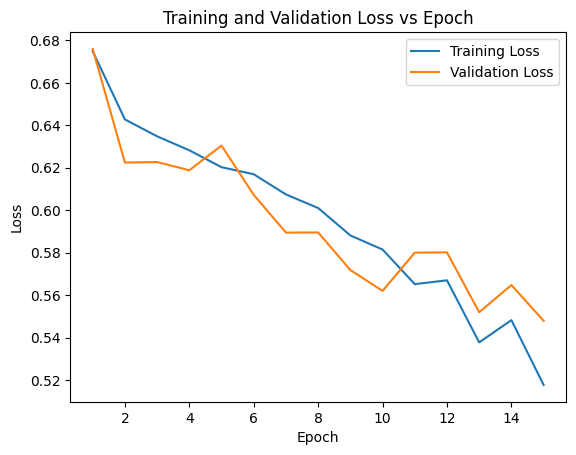

Saved loss graph: /content/cardiomegaly_project/figures/training_validation_loss.png


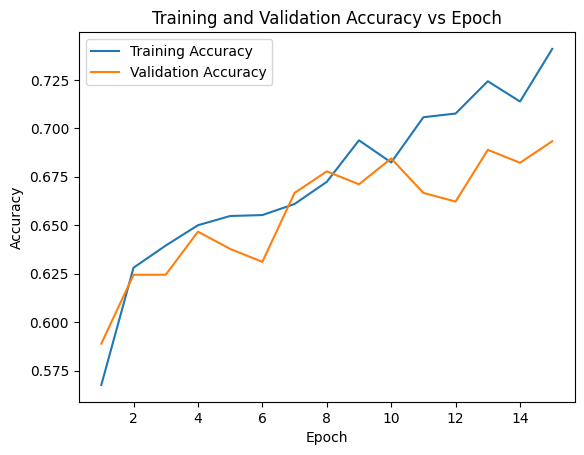

Saved accuracy graph: /content/cardiomegaly_project/figures/training_validation_accuracy.png


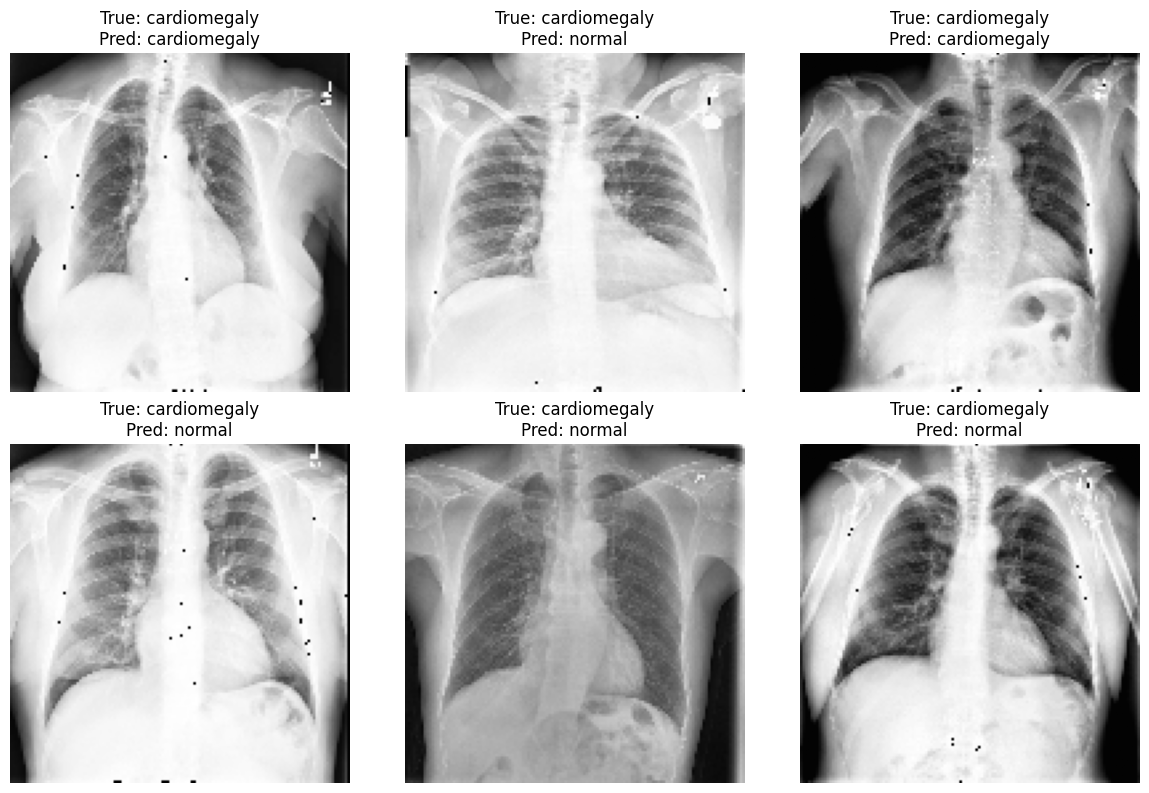

Saved example predictions: /content/cardiomegaly_project/figures/example_predictions.png
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Created submission zip: /content/cardiomegaly_project/cardiomegaly_project_outputs.zip
Done.


In [21]:
# =========================================================
# 0. Install and import packages
# =========================================================

!pip -q install kaggle

import os
import glob
import shutil
import random
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from PIL import Image

# =========================================================
# 1. Setup project directories
# =========================================================

project_root = "/content/cardiomegaly_project"
raw_dir = os.path.join(project_root, "raw")
dataset_dir = os.path.join(project_root, "dataset")
figures_dir = os.path.join(project_root, "figures")
outputs_dir = os.path.join(project_root, "outputs")

for d in [raw_dir, dataset_dir, figures_dir, outputs_dir]:
    os.makedirs(d, exist_ok=True)

# =========================================================
# 2. Download Kaggle dataset
# =========================================================
# Recommended dataset:
# https://www.kaggle.com/datasets/rahimanshu/cardiomegaly-disease-prediction-using-cnn

KAGGLE_DATASET = "rahimanshu/cardiomegaly-disease-prediction-using-cnn"

print("Downloading dataset:", KAGGLE_DATASET)
!kaggle datasets download -d {KAGGLE_DATASET} -p "{raw_dir}" --unzip

print("\nDownloaded files preview:")
!find "{raw_dir}" -maxdepth 4 -type f | head -50

# =========================================================
# 3. Helper functions
# =========================================================

def is_image_file(path):
    return Path(path).suffix.lower() in [".jpg", ".jpeg", ".png", ".bmp"]

def safe_copy_image(src, dst):
    """
    Opens image, converts to RGB, and saves it.
    This avoids issues with grayscale or unusual image modes.
    """
    try:
        img = Image.open(src).convert("RGB")
        img.save(dst)
        return True
    except Exception as e:
        print("Failed image:", src, "| Error:", e)
        return False

def clean_and_make_imagefolder():
    """
    Creates:
    dataset/
      train/
        normal/
        cardiomegaly/
      val/
        normal/
        cardiomegaly/
      test/
        normal/
        cardiomegaly/
    """
    if os.path.exists(dataset_dir):
        shutil.rmtree(dataset_dir)

    for split in ["train", "val", "test"]:
        for cls in ["normal", "cardiomegaly"]:
            os.makedirs(os.path.join(dataset_dir, split, cls), exist_ok=True)

def split_and_copy(image_paths_by_class, max_per_class=1500):
    """
    Takes:
      {"normal": [...], "cardiomegaly": [...]}

    Creates balanced train/val/test ImageFolder dataset.
    """
    clean_and_make_imagefolder()
    random.seed(42)

    min_count = min(len(image_paths_by_class["normal"]), len(image_paths_by_class["cardiomegaly"]))
    if min_count == 0:
        raise ValueError("One class has zero images. Cannot train binary classifier.")

    limit = min(min_count, max_per_class)

    print("\nUsing balanced class size:", limit, "images per class")

    for cls, paths in image_paths_by_class.items():
        paths = list(paths)
        random.shuffle(paths)
        paths = paths[:limit]

        n = len(paths)
        n_train = int(0.70 * n)
        n_val = int(0.15 * n)

        split_dict = {
            "train": paths[:n_train],
            "val": paths[n_train:n_train+n_val],
            "test": paths[n_train+n_val:]
        }

        for split, split_paths in split_dict.items():
            for i, src in enumerate(split_paths):
                dst_name = f"{cls}_{i:05d}{Path(src).suffix.lower()}"
                dst = os.path.join(dataset_dir, split, cls, dst_name)
                safe_copy_image(src, dst)

# =========================================================
# 4. Find all image files
# =========================================================

all_image_files = [
    f for f in glob.glob(os.path.join(raw_dir, "**", "*"), recursive=True)
    if is_image_file(f)
]

print("\nTotal image files found:", len(all_image_files))

if len(all_image_files) == 0:
    raise FileNotFoundError("No image files found in the downloaded dataset.")

# =========================================================
# Dataset-specific folder detection
# This Kaggle dataset uses:
# false = normal
# true  = cardiomegaly
# =========================================================

all_image_files = [
    f for f in glob.glob(os.path.join(raw_dir, "**", "*"), recursive=True)
    if is_image_file(f)
]

print("\nTotal image files found:", len(all_image_files))

normal_candidates = []
cardio_candidates = []

for f in all_image_files:
    parts = [p.lower() for p in Path(f).parts]

    if "false" in parts:
        normal_candidates.append(f)

    elif "true" in parts:
        cardio_candidates.append(f)

print("\nDetected class counts from true/false folders:")
print("normal / false:", len(normal_candidates))
print("cardiomegaly / true:", len(cardio_candidates))

if len(normal_candidates) == 0 or len(cardio_candidates) == 0:
    raise ValueError(
        "Could not find both false and true folders. "
        "Check the dataset folder structure."
    )

image_paths_by_class = {
    "normal": normal_candidates,
    "cardiomegaly": cardio_candidates
}

split_and_copy(image_paths_by_class, max_per_class=1500)
# =========================================================
# 7. Verify final ImageFolder structure
# =========================================================

print("\nFinal dataset counts:")
for split in ["train", "val", "test"]:
    print(split)
    for cls in ["normal", "cardiomegaly"]:
        count = len(glob.glob(os.path.join(dataset_dir, split, cls, "*")))
        print(" ", cls, count)

!find "/content/cardiomegaly_project/dataset" -maxdepth 3 -type d


# =========================================================
# 8. PyTorch ImageFolder datasets
# =========================================================

image_size = 128
batch_size = 32

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

eval_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_dir, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_dir, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(dataset_dir, "test"),
    transform=eval_transform
)

print("\nClasses:", train_dataset.classes)
print("Class to index:", train_dataset.class_to_idx)
print("Train images:", len(train_dataset))
print("Val images:", len(val_dataset))
print("Test images:", len(test_dataset))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# =========================================================
# 9. Simple CNN model
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * (image_size // 8) * (image_size // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=2).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print(model)

# =========================================================
# 10. Train / evaluation functions
# =========================================================

def run_epoch(dataloader, model, loss_fn, optimizer=None):
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss = 0.0
    total_correct = 0
    total_count = 0

    for X, y in dataloader:
        X = X.to(device)
        y = y.to(device)

        if optimizer is None:
            with torch.no_grad():
                pred = model(X)
                loss = loss_fn(pred, y)
        else:
            pred = model(X)
            loss = loss_fn(pred, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_correct += (pred.argmax(1) == y).sum().item()
        total_count += y.size(0)

    avg_loss = total_loss / len(dataloader)
    avg_acc = total_correct / total_count

    return avg_loss, avg_acc

# =========================================================
# 11. Training
# =========================================================

epochs = 15

train_losses = []
val_losses = []
train_accs = []
val_accs = []
log_lines = []

for epoch in range(epochs):
    train_loss, train_acc = run_epoch(train_loader, model, loss_fn, optimizer)
    val_loss, val_acc = run_epoch(val_loader, model, loss_fn)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    line = (
        f"Epoch {epoch+1:02d} | "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )

    print(line)
    log_lines.append(line)

# =========================================================
# 12. Final test evaluation
# =========================================================

test_loss, test_acc = run_epoch(test_loader, model, loss_fn)

test_line = f"Final test_loss={test_loss:.4f}, test_acc={test_acc:.4f}"
print("\n" + test_line)
log_lines.append(test_line)

# =========================================================
# 13. Save training statistics
# =========================================================

stats_path = os.path.join(outputs_dir, "training_stats.txt")

with open(stats_path, "w") as f:
    for line in log_lines:
        f.write(line + "\n")

print("\nSaved training statistics:", stats_path)

# =========================================================
# 14. Save model
# =========================================================

model_path = os.path.join(outputs_dir, "cardiomegaly_simple_cnn.pth")
torch.save(model.state_dict(), model_path)

print("Saved model:", model_path)

# =========================================================
# 15. Plot loss graph
# =========================================================

plt.figure()
plt.plot(range(1, epochs + 1), train_losses, label="Training Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()

loss_fig_path = os.path.join(figures_dir, "training_validation_loss.png")
plt.savefig(loss_fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved loss graph:", loss_fig_path)

# =========================================================
# 16. Plot accuracy graph
# =========================================================

plt.figure()
plt.plot(range(1, epochs + 1), train_accs, label="Training Accuracy")
plt.plot(range(1, epochs + 1), val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs Epoch")
plt.legend()

acc_fig_path = os.path.join(figures_dir, "training_validation_accuracy.png")
plt.savefig(acc_fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved accuracy graph:", acc_fig_path)

# =========================================================
# 17. Save example predictions
# =========================================================

model.eval()

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

example_fig_path = os.path.join(figures_dir, "example_predictions.png")

images_shown = 0
max_examples = 6

plt.figure(figsize=(12, 8))

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        pred = model(X)
        pred_class = pred.argmax(1).cpu()
        X_cpu = X.cpu()

        for i in range(X_cpu.size(0)):
            if images_shown >= max_examples:
                break

            img = X_cpu[i].permute(1, 2, 0).numpy()
            true_label = idx_to_class[int(y[i])]
            pred_label = idx_to_class[int(pred_class[i])]

            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"True: {true_label}\nPred: {pred_label}")

            images_shown += 1

        if images_shown >= max_examples:
            break

plt.tight_layout()
plt.savefig(example_fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved example predictions:", example_fig_path)

# =========================================================
# 18. Save small outputs for GitHub / Brightspace
# =========================================================
# Do NOT include the raw dataset.
# Your course says no large datasets, binaries, or large files.

# Mount Google Drive and redefine paths for submission if desired
from google.colab import drive
drive.mount('/content/drive')

# Redefine project_root and other relevant paths for saving to Google Drive
drive_project_root = "/content/drive/MyDrive/Colab Notebooks/BME/Cardiomegaly_Project"
drive_outputs_dir = os.path.join(drive_project_root, "outputs")
drive_figures_dir = os.path.join(drive_project_root, "figures")

os.makedirs(drive_outputs_dir, exist_ok=True)
os.makedirs(drive_figures_dir, exist_ok=True)

# Copy outputs to the Drive-based outputs directory
shutil.copy(stats_path, os.path.join(drive_outputs_dir, os.path.basename(stats_path)))
shutil.copy(model_path, os.path.join(drive_outputs_dir, os.path.basename(model_path)))
shutil.copy(loss_fig_path, os.path.join(drive_figures_dir, os.path.basename(loss_fig_path)))
shutil.copy(acc_fig_path, os.path.join(drive_figures_dir, os.path.basename(acc_fig_path)))
shutil.copy(example_fig_path, os.path.join(drive_figures_dir, os.path.basename(example_fig_path)))

submission_dir = os.path.join(project_root, "submission_files")

if os.path.exists(submission_dir):
    shutil.rmtree(submission_dir)

os.makedirs(submission_dir, exist_ok=True)

shutil.copy(stats_path, os.path.join(submission_dir, "training_stats.txt"))
shutil.copy(loss_fig_path, os.path.join(submission_dir, "training_validation_loss.png"))
shutil.copy(acc_fig_path, os.path.join(submission_dir, "training_validation_accuracy.png"))
shutil.copy(example_fig_path, os.path.join(submission_dir, "example_predictions.png"))

readme_outputs_path = os.path.join(submission_dir, "README_outputs.txt")

with open(readme_outputs_path, "w") as f:
    f.write("Project: Deep Learning-Based Detection of Cardiomegaly from Chest X-ray Images\n")
    f.write("Task: Binary classification\n")
    f.write("Classes: normal, cardiomegaly\n")
    f.write("Input: single chest X-ray image\n")
    f.write("Model: Simple CNN\n")
    f.write("Loss: CrossEntropyLoss\n")
    f.write("Optimizer: Adam\n")
    f.write("Generated outputs:\n")
    f.write("- training_stats.txt\n")
    f.write("- training_validation_loss.png\n")
    f.write("- training_validation_accuracy.png\n")
    f.write("- example_predictions.png\n")

zip_path = os.path.join(project_root, "cardiomegaly_project_outputs.zip")

if os.path.exists(zip_path):
    os.remove(zip_path)

shutil.make_archive(
    base_name=zip_path.replace(".zip", ""),
    format="zip",
    root_dir=submission_dir
)

print("\nCreated submission zip:", zip_path)
print("Done.")